In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Read in the data
codecademy = pd.read_csv('codecademy.csv')

In [2]:
# Print the first five rows
print(codecademy.head())

   score  completed    lesson
0   82.7       35.0  Lesson A
1   65.2       31.0  Lesson A
2   55.3       33.0  Lesson A
3   28.8       25.0  Lesson B
4   31.2       18.0  Lesson B


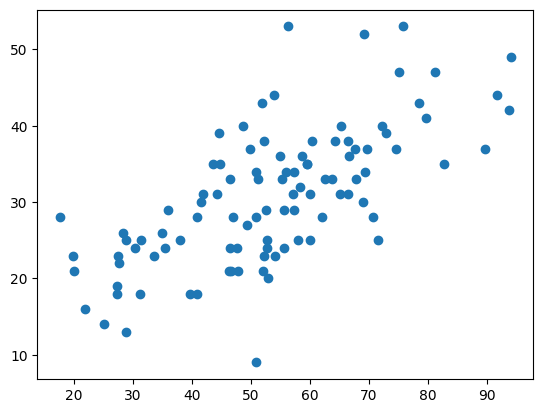

<Figure size 640x480 with 0 Axes>

In [28]:
# Create a scatter plot of score vs completed
plt.scatter(codecademy.score, codecademy.completed)
plt.show()
plt.clf()

In [5]:
# Fit a linear regression to predict score based on prior lessons completed
model = sm.OLS.from_formula('score ~ completed', codecademy)
results = model.fit()
print(results.params)

Intercept    13.214113
completed     1.306826
dtype: float64


### Intercept interpretation:
A learner who has previously completed 0 content items is expected to earn a quiz score of 13.2 points.

### Slope interpretation:
Students who have completed one additional prior content item are expected to score 1.3 points higher on the quiz.

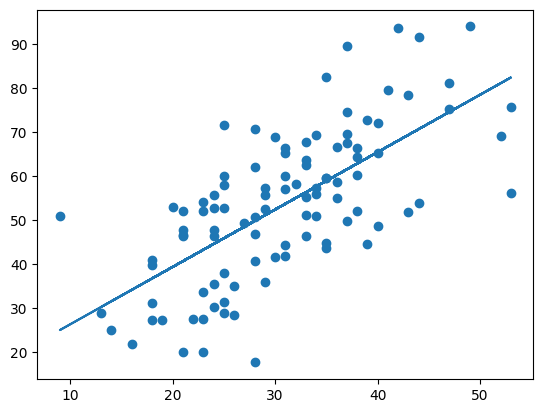

<Figure size 640x480 with 0 Axes>

In [27]:
# Plot the scatter plot with the line on top
plt.scatter(codecademy.completed, codecademy.score)
plt.plot(codecademy.completed, results.predict(codecademy))
plt.show()
plt.clf()

In [8]:
# Predict score for learner who has completed 20 prior lessons
pred20_m = results.params.iloc[0] + results.params.iloc[1]*20

pred20_p = results.predict({'completed':[20]})[0]
print(f"Params: {pred20_m}" )
print(f"Predict: {pred20_p}" )


Params: 39.35062487732294
Predict: 39.35062487732294


In [21]:
# Calculate fitted values
fitted_values = results.predict(codecademy)
print(fitted_values.head())

0    58.953009
1    53.725706
2    56.339358
3    45.884753
4    36.736974
dtype: float64


In [23]:
# Calculate residuals
residuals = codecademy.score - fitted_values
print(residuals.head())

0    23.746991
1    11.474294
2    -1.039358
3   -17.084753
4    -5.536974
dtype: float64


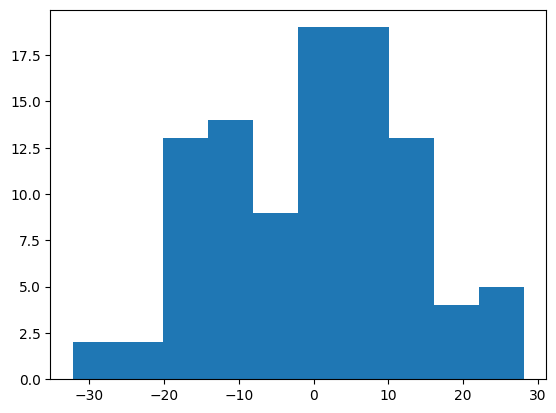

<Figure size 640x480 with 0 Axes>

In [26]:
# Check normality assumption
plt.hist(residuals)
plt.show()
plt.clf()

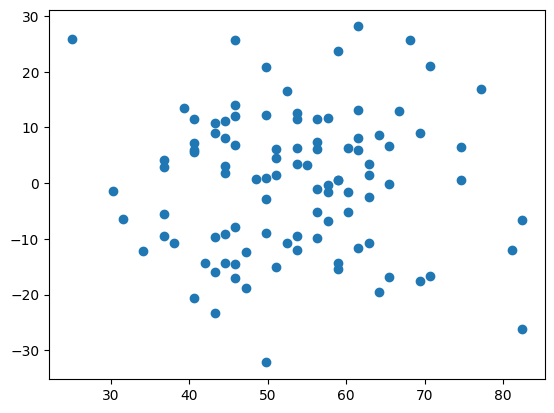

<Figure size 640x480 with 0 Axes>

In [30]:
# Check homoscedasticity assumption
plt.scatter(fitted_values, residuals)
plt.show()
plt.clf()

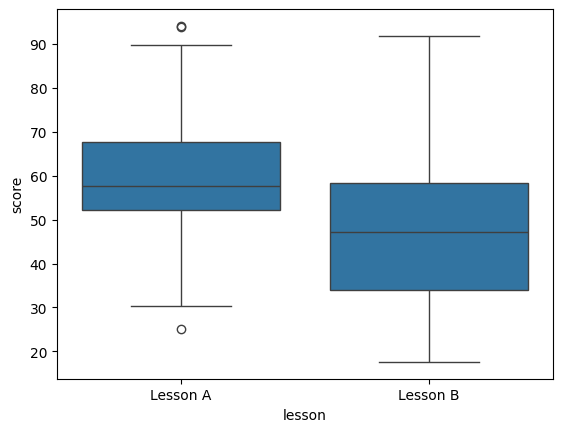

<Figure size 640x480 with 0 Axes>

In [31]:
# Create a boxplot of score vs lesson
sns.boxplot(x = 'lesson', y = 'score', data = codecademy)
plt.show()
plt.clf()

In [32]:
# Fit a linear regression to predict score based on which lesson they took
model = sm.OLS.from_formula('score ~ lesson', codecademy)
results = model.fit()
print(results.params)

Intercept             59.220
lesson[T.Lesson B]   -11.642
dtype: float64


In [53]:
# Calculate and print the group means and mean difference (for comparison)
# Calculate and print the group means (for comparison)
mean_lesson_a = np.mean(codecademy.score[codecademy.lesson == 'Lesson A'])
mean_lesson_b = np.mean(codecademy.score[codecademy.lesson == 'Lesson B'])
print(f'Mean score (Lesson A): {mean_lesson_a:.2f}')
print(f'Mean score (Lesson B): {mean_lesson_b:.2f}')
print(f'Mean score difference: {mean_lesson_a - mean_lesson_b:.2f}')

print()
group_means = codecademy.groupby('lesson')['score'].mean()
print(group_means)
# Calculate difference
mean_diff = group_means['Lesson A'] - group_means['Lesson B']
print(f'Mean score difference: {mean_diff:.2f}')

Mean score (Lesson A): 59.22
Mean score (Lesson B): 47.58
Mean score difference: 11.64

lesson
Lesson A    59.220
Lesson B    47.578
Name: score, dtype: float64
Mean score difference: 11.64


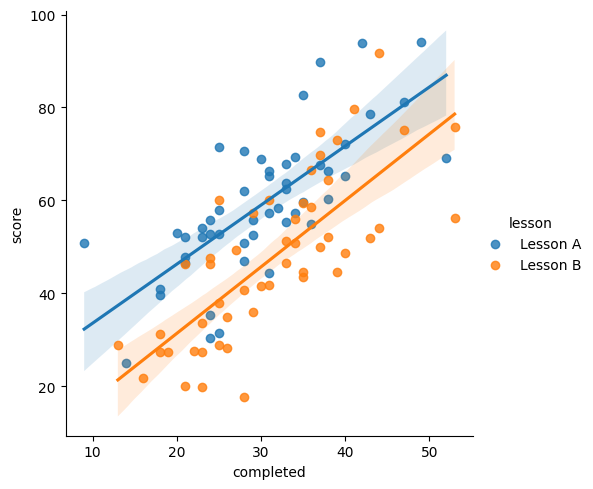

In [46]:
# Use `sns.lmplot()` to plot `score` vs. `completed` colored by `lesson`
sns.lmplot(x = 'completed', y = 'score', hue = 'lesson', data = codecademy)
plt.show()